## Idealized Wind Experiments
The idea with this notebook is to try to get at the physics behind the impacts of wind forcing beyond simple local Ekman tranport.

### Baseline model output
Its clear even from an Atlantic-only model that high-latitude winds have a greater effect on thickness anomalies outside the western boundary region.
We have that $h_b = h_e e^{-i\omega L/c} - \int_{x_b}^{x_e} \frac{w_{Ek}}{c}e^{i\omega(x_b-x')/c}\,dx'$, so that the shelf anomaly due to upwelling along Rossby waves is of the order $\frac{L}{c}w_{Ek}$. This means that at high-latitudes, where $c$ is small, and also south of Africa where $L$ is large, we can expect larger anomalies to occur. We see that this is the case in $h_b$ across the east coast of the Americas, in the cells below.

In [49]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from moc_adjustment_theory import rossby_speed, EARTH_RADIUS_M

In [115]:
output_ds = xr.open_dataset("/Users/awatford/Documents/GitHub/MOCAdjustmentTheory/data/untracked/model_output/global_rossby_model_solution.zarr")
isobath_ds = xr.open_dataset(output_ds.isobath)
forcing_ds = xr.open_dataset(output_ds.forcing)

In [51]:
# Extract h_b
h_b_na = output_ds.h_b.sel(region="north_atlantic").drop_vars("region").dropna(dim="latitude", how="all").sortby("latitude", ascending=True)
h_b_ai = output_ds.h_b.sel(region="atlantic_indian").drop_vars("region").dropna(dim="latitude", how="all").sortby("latitude", ascending=True)
h_b_ap = output_ds.h_b.sel(region="atlantic_pacific").drop_vars("region").dropna(dim="latitude", how="all").sortby("latitude", ascending=True)
h_b = xr.concat([h_b_ap, h_b_ai, h_b_na], dim="latitude").sortby("latitude", ascending=True)

In [74]:
# Build the eastern and western boundary traces
x_w = isobath_ds.x_wA.dropna("latitude").sortby("latitude", ascending=True)
x_eA = isobath_ds.x_eA.dropna("latitude").sortby("latitude", ascending=True)
y_I = x_eA.latitude.min()
x_eI = isobath_ds.x_eI.dropna("latitude").sortby("latitude", ascending=True).sel(latitude=slice(None, y_I)).isel(latitude=slice(None, -1))
y_P = x_eI.latitude.min()
x_eP = isobath_ds.x_eP.dropna("latitude").sortby("latitude", ascending=True).sel(latitude=slice(None, y_P)).isel(latitude=slice(None, -1))
x_e = xr.concat([x_eP, x_eI, x_eA], dim="latitude").sortby("latitude", ascending=True)

In [89]:
# Compute travel times
g = output_ds.attrs["g_prime_m_s-2"]
H = output_ds.attrs["isobath_depth_m"]
L = EARTH_RADIUS_M * np.cos(np.radians(x_w.latitude)) * np.radians(x_e - x_w)
c = rossby_speed(L.latitude, g, H)
tt = L / c

(-55.0, 55.0)

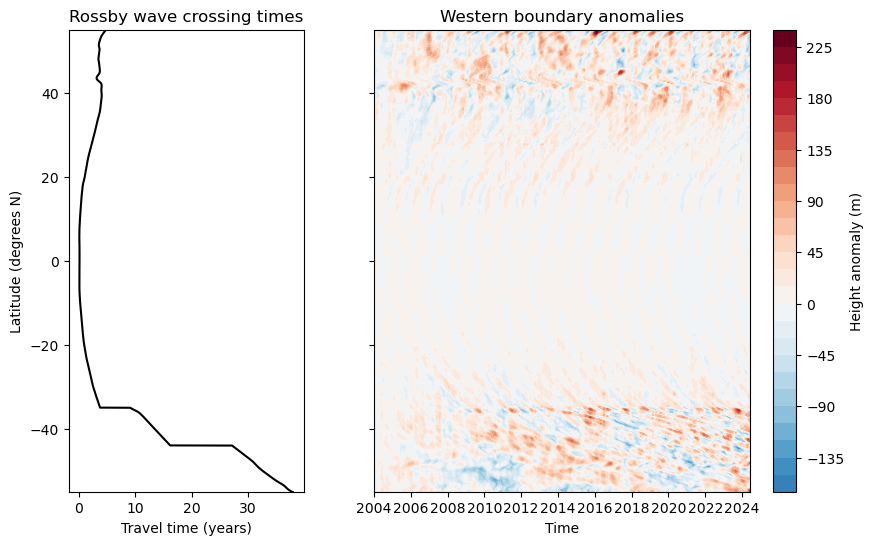

In [121]:
## Create a two-panel figure to plot the travel times and western boundary anomalies in the Atlantic
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), sharey=True, width_ratios=[1, 2])
# Plot travel times
tt_yr = tt / (24 * 60 * 60 * 365.25) # Convert seconds to years
tt_ax = axs[0]
tt_ax.plot(tt_yr, tt_yr.latitude, color="black")
tt_ax.set_xlabel("Travel time (years)")
tt_ax.set_ylabel("Latitude (degrees N)")
tt_ax.set_title("Rossby wave crossing times")
# Plot height anomalies
h_b_ax = axs[1]
vmax = np.max(np.abs(h_b.T))
ctf = h_b_ax.contourf(h_b.time, h_b.latitude, h_b.T, cmap="RdBu_r", levels=31, vmin=-vmax, vmax=vmax)
h_b_ax.set_xlabel("Time")
plt.colorbar(ctf, ax=h_b_ax, label="Height anomaly (m)")
h_b_ax.set_title("Western boundary anomalies")
h_b_ax.set_ylim([h_b.latitude.min(), h_b.latitude.max()])

Interestingly, the magnitude of the anomalies in the far South Atlantic are similar to those in the North Atlantic, even though the crossing times are much longer in the South. This indicates stronger mean North Atlantic wind anomalies along the Rossby waves. We can compare the variability in $h_b$ as a function of latitude to the zonal mean variability in $w_{Ek}$ also as a function of latitude:
$$\sigma_{h_b} \sim \frac{L}{c} \sigma_{w_{Ek}}$$

In [173]:
# Compute the Ekman upwelling as the divergence of the forcing
x_contribution = forcing_ds.M_Ek_x.differentiate("longitude") / (EARTH_RADIUS_M * np.cos(np.radians(forcing_ds.latitude)) * np.radians(1))
y_contribution = (forcing_ds.M_Ek_y * np.cos(np.radians(forcing_ds.latitude))).differentiate("latitude") / (EARTH_RADIUS_M * np.cos(np.radians(forcing_ds.latitude)) * np.radians(1))
w_Ek = (x_contribution + y_contribution)
# Mask the upwelling only to the Atlantic basin
x_w_forcing = x_w.interp(latitude=w_Ek.latitude)
x_e_forcing = x_e.interp(latitude=w_Ek.latitude)

spatial_mask = (
    (w_Ek.longitude >= x_w_forcing)
    & (w_Ek.longitude <= x_e_forcing)
)
w_Ek_atlantic = w_Ek.where(spatial_mask)
zonal_mean_w_Ek_std = w_Ek_atlantic.std(dim="time").mean(dim="longitude")

In [196]:
# Ccompute the variability in h_b as a function of latitude
h_b_std = h_b.std(dim="time")
# Product of travel time and Ekman upwelling variability
tt_on_forcing = tt.interp(latitude=zonal_mean_w_Ek_std.latitude)
tau_times_w_Ek_std = tt_on_forcing * zonal_mean_w_Ek_std
tau_times_w_Ek_std = tau_times_w_Ek_std.interp(latitude=h_b_std.latitude)

Text(0.5, 1.0, 'Scatter plot of the two variabilities')

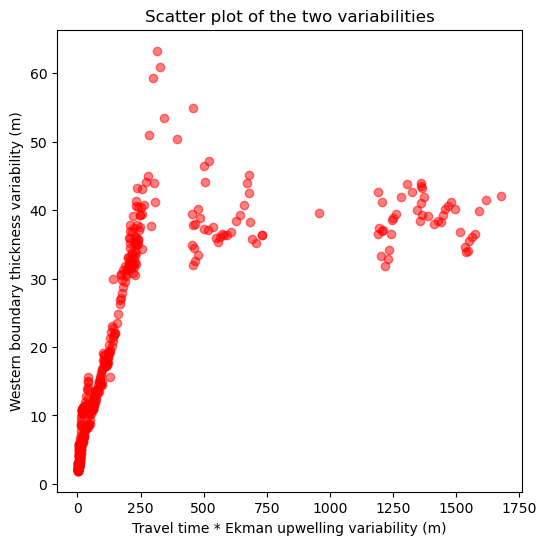

In [204]:
## Create a figure
fig = plt.figure(figsize=(6, 6))
scatter_ax = fig.add_subplot(111)
scatter_ax.scatter(tau_times_w_Ek_std, h_b_std, color="red", alpha=0.5)
scatter_ax.set_xlabel("Travel time * Ekman upwelling variability (m)")
scatter_ax.set_ylabel("Western boundary thickness variability (m)")
scatter_ax.set_title("Scatter plot of the two variabilities")
# scatter_ax.set_xscale("log")
# scatter_ax.set_yscale("log")